# Model Training v2 — 滑动窗口 + 高级融合策略
**date**: 2026-04-14

数据策略：
- **训练集** = 滑动窗口1（1.1-4.13 → 4.14-5.14）+ 窗口2（2.1-5.14 → 5.15-6.15）合并
- **测试集** = 618 促销期预测（特征 3.15-6.15，标签 6.16-6.30）

融合策略：
1. **自适应权重寻优**（Adaptive Weight Search）
2. **Stacking 堆叠泛化**（XGB + LGB → L2 逻辑回归）
3. **尤登指数最优阈值**（Youden's J Statistic）


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import pickle, os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
print('Libraries ready.')


Libraries ready.


## 1. 加载数据

In [2]:
train_combined = pd.read_csv('../data/features/train_combined.csv')
test_618       = pd.read_csv('../data/features/test_618.csv')

feature_cols = [c for c in train_combined.columns if c not in ('user_id', 'label')]
print(f'训练集 shape: {train_combined.shape}  正样本率: {train_combined["label"].mean()*100:.2f}%')
print(f'测试集 shape: {test_618.shape}         正样本率: {test_618["label"].mean()*100:.2f}%')
print(f'特征数: {len(feature_cols)}')


训练集 shape: (1243538, 47)  正样本率: 47.09%
测试集 shape: (638373, 47)         正样本率: 32.62%
特征数: 45


## 2. 训练 / 验证集划分

In [3]:
X = train_combined[feature_cols]
y = train_combined['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_test = test_618[feature_cols]
y_test = test_618['label']

print(f'训练集: {X_train.shape}  正样本率: {y_train.mean()*100:.2f}%')
print(f'验证集: {X_val.shape}    正样本率: {y_val.mean()*100:.2f}%')
print(f'测试集: {X_test.shape}   正样本率: {y_test.mean()*100:.2f}%')


训练集: (932653, 45)  正样本率: 47.09%
验证集: (310885, 45)    正样本率: 47.09%
测试集: (638373, 45)   正样本率: 32.62%


## 3. 训练 XGBoost

In [4]:
xgb_params = dict(
    max_depth=6, learning_rate=0.05, n_estimators=500,
    objective='binary:logistic', eval_metric='auc',
    colsample_bytree=0.8, subsample=0.8,
    early_stopping_rounds=30,
    random_state=42, n_jobs=-1, verbosity=0
)

print('训练 XGBoost ...')
xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_prob_val  = xgb_model.predict_proba(X_val)[:, 1]
y_prob_test = xgb_model.predict_proba(X_test)[:, 1]

print(f'XGBoost  验证集 AUC: {roc_auc_score(y_val,  y_prob_val):.4f}')
print(f'XGBoost  测试集 AUC: {roc_auc_score(y_test, y_prob_test):.4f}')


训练 XGBoost ...
XGBoost  验证集 AUC: 0.7128
XGBoost  测试集 AUC: 0.7180


## 4. 训练 LightGBM

In [5]:
lgb_params = dict(
    objective='binary', metric='auc', boosting_type='gbdt',
    n_estimators=500, learning_rate=0.05, max_depth=6,
    num_leaves=31, feature_fraction=0.8, bagging_fraction=0.8,
    bagging_freq=5, random_state=42, n_jobs=-1, verbosity=-1
)

print('训练 LightGBM ...')
lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)]
)

y_prob_val_lgb  = lgb_model.predict_proba(X_val)[:, 1]
y_prob_test_lgb = lgb_model.predict_proba(X_test)[:, 1]

print(f'LightGBM 验证集 AUC: {roc_auc_score(y_val,  y_prob_val_lgb):.4f}')
print(f'LightGBM 测试集 AUC: {roc_auc_score(y_test, y_prob_test_lgb):.4f}')


训练 LightGBM ...
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[254]	valid_0's auc: 0.712611
LightGBM 验证集 AUC: 0.7126
LightGBM 测试集 AUC: 0.7181


## 5. 高级融合策略

策略1：自适应权重寻优
最优 XGBoost 权重 w = 0.67  (LGBM = 0.33)
验证集最高 AUC:      0.7128
测试集融合 AUC:      0.7181


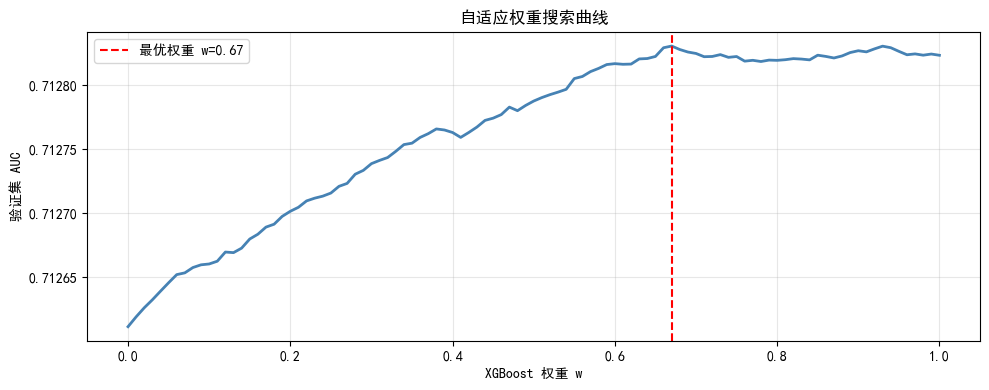

In [6]:
# ============================================================
# 策略 1：自适应权重寻优 (Adaptive Weight Search)
# 在验证集上以 0.01 步长遍历 XGBoost 权重 w，LGBM 权重 = 1 - w
# ============================================================
print('=' * 60)
print('策略1：自适应权重寻优')
print('=' * 60)

best_w, best_val_auc = 0.5, 0.0
weight_results = []

for w in np.arange(0.0, 1.01, 0.01):
    w = round(w, 2)
    blend_val = w * y_prob_val + (1 - w) * y_prob_val_lgb
    val_auc   = roc_auc_score(y_val, blend_val)
    weight_results.append({'xgb_weight': w, 'val_auc': val_auc})
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_w = w

print(f'最优 XGBoost 权重 w = {best_w:.2f}  (LGBM = {1-best_w:.2f})')
print(f'验证集最高 AUC:      {best_val_auc:.4f}')

# 用最优权重生成测试集融合概率
y_prob_ensemble = best_w * y_prob_test + (1 - best_w) * y_prob_test_lgb
ensemble_auc    = roc_auc_score(y_test, y_prob_ensemble)
print(f'测试集融合 AUC:      {ensemble_auc:.4f}')

# 可视化
weight_df = pd.DataFrame(weight_results)
plt.figure(figsize=(10, 4))
plt.plot(weight_df['xgb_weight'], weight_df['val_auc'], color='steelblue', lw=2)
plt.axvline(x=best_w, color='red', linestyle='--', label=f'最优权重 w={best_w:.2f}')
plt.xlabel('XGBoost 权重 w'); plt.ylabel('验证集 AUC')
plt.title('自适应权重搜索曲线')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


In [7]:
# ============================================================
# 策略 2：Stacking 堆叠泛化
# 第一层：XGBoost + LightGBM
# 第二层：L2 正则化逻辑回归（元模型）
# ============================================================
print('\n' + '=' * 60)
print('策略2：Stacking 堆叠泛化')
print('=' * 60)

# Base estimators（去掉 early_stopping_rounds，兼容 StackingClassifier 的 CV 流程）
base_xgb = xgb.XGBClassifier(
    max_depth=6, learning_rate=0.05, n_estimators=300,
    objective='binary:logistic', eval_metric='auc',
    colsample_bytree=0.8, subsample=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
base_lgb = lgb.LGBMClassifier(
    objective='binary', metric='auc', boosting_type='gbdt',
    n_estimators=300, learning_rate=0.05, max_depth=6,
    num_leaves=31, feature_fraction=0.8, bagging_fraction=0.8,
    bagging_freq=5, random_state=42, n_jobs=-1, verbosity=-1
)
meta_lr = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(
    estimators=[('xgb', base_xgb), ('lgb', base_lgb)],
    final_estimator=meta_lr,
    cv=5, stack_method='predict_proba', n_jobs=-1
)

print('训练 Stacking 模型（5 折 CV，耗时约数分钟）...')
stacking_clf.fit(X_train, y_train)

y_prob_val_stack  = stacking_clf.predict_proba(X_val)[:, 1]
y_prob_test_stack = stacking_clf.predict_proba(X_test)[:, 1]
stacking_val_auc  = roc_auc_score(y_val,  y_prob_val_stack)
stacking_test_auc = roc_auc_score(y_test, y_prob_test_stack)

print(f'Stacking 验证集 AUC: {stacking_val_auc:.4f}')
print(f'Stacking 测试集 AUC: {stacking_test_auc:.4f}')

print(f'\n--- AUC 汇总对比 ---')
print(f'单模型 XGBoost:              {roc_auc_score(y_test, y_prob_test):.4f}')
print(f'单模型 LightGBM:             {roc_auc_score(y_test, y_prob_test_lgb):.4f}')
print(f'软投票 (最优权重 w={best_w:.2f}):   {ensemble_auc:.4f}')
print(f'Stacking (LR Meta):          {stacking_test_auc:.4f}')



策略2：Stacking 堆叠泛化
训练 Stacking 模型（5 折 CV，耗时约数分钟）...
Stacking 验证集 AUC: 0.7128
Stacking 测试集 AUC: 0.7181

--- AUC 汇总对比 ---
单模型 XGBoost:              0.7180
单模型 LightGBM:             0.7181
软投票 (最优权重 w=0.67):   0.7181
Stacking (LR Meta):          0.7181


In [8]:
# ============================================================
# 策略 3：尤登指数最优阈值 (Youden's J Statistic)
# 在验证集 ROC 曲线上找 TPR-FPR 最大的阈值，用于测试集 F1
# ============================================================
print('\n' + '=' * 60)
print('策略3：尤登指数最优阈值')
print('=' * 60)

# 验证集融合概率
y_prob_val_ens = best_w * y_prob_val + (1 - best_w) * y_prob_val_lgb

fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_prob_val_ens)
youden_j  = tpr_val - fpr_val
best_idx  = np.argmax(youden_j)
optimal_threshold = thresholds_val[best_idx]

print(f'最优阈值 (Youden\'s J): {optimal_threshold:.4f}')
print(f'最大尤登指数 J:        {youden_j[best_idx]:.4f}  '
      f'(TPR={tpr_val[best_idx]:.4f}, FPR={fpr_val[best_idx]:.4f})')

y_pred_youden = (y_prob_ensemble >= optimal_threshold).astype(int)
y_pred_05     = (y_prob_ensemble >= 0.5).astype(int)

print(f'\n--- 测试集 F1 对比 ---')
print(f'固定阈值 0.50:                   F1={f1_score(y_test, y_pred_05):.4f}')
print(f'尤登最优阈值 {optimal_threshold:.4f}:   '
      f'F1={f1_score(y_test, y_pred_youden):.4f}  '
      f'Precision={precision_score(y_test, y_pred_youden):.4f}  '
      f'Recall={recall_score(y_test, y_pred_youden):.4f}')

best_threshold = optimal_threshold
y_pred_final   = y_pred_youden



策略3：尤登指数最优阈值
最优阈值 (Youden's J): 0.4724
最大尤登指数 J:        0.3097  (TPR=0.5942, FPR=0.2845)

--- 测试集 F1 对比 ---
固定阈值 0.50:                   F1=0.5519
尤登最优阈值 0.4724:   F1=0.5584  Precision=0.4843  Recall=0.6591


## 6. 可视化评估

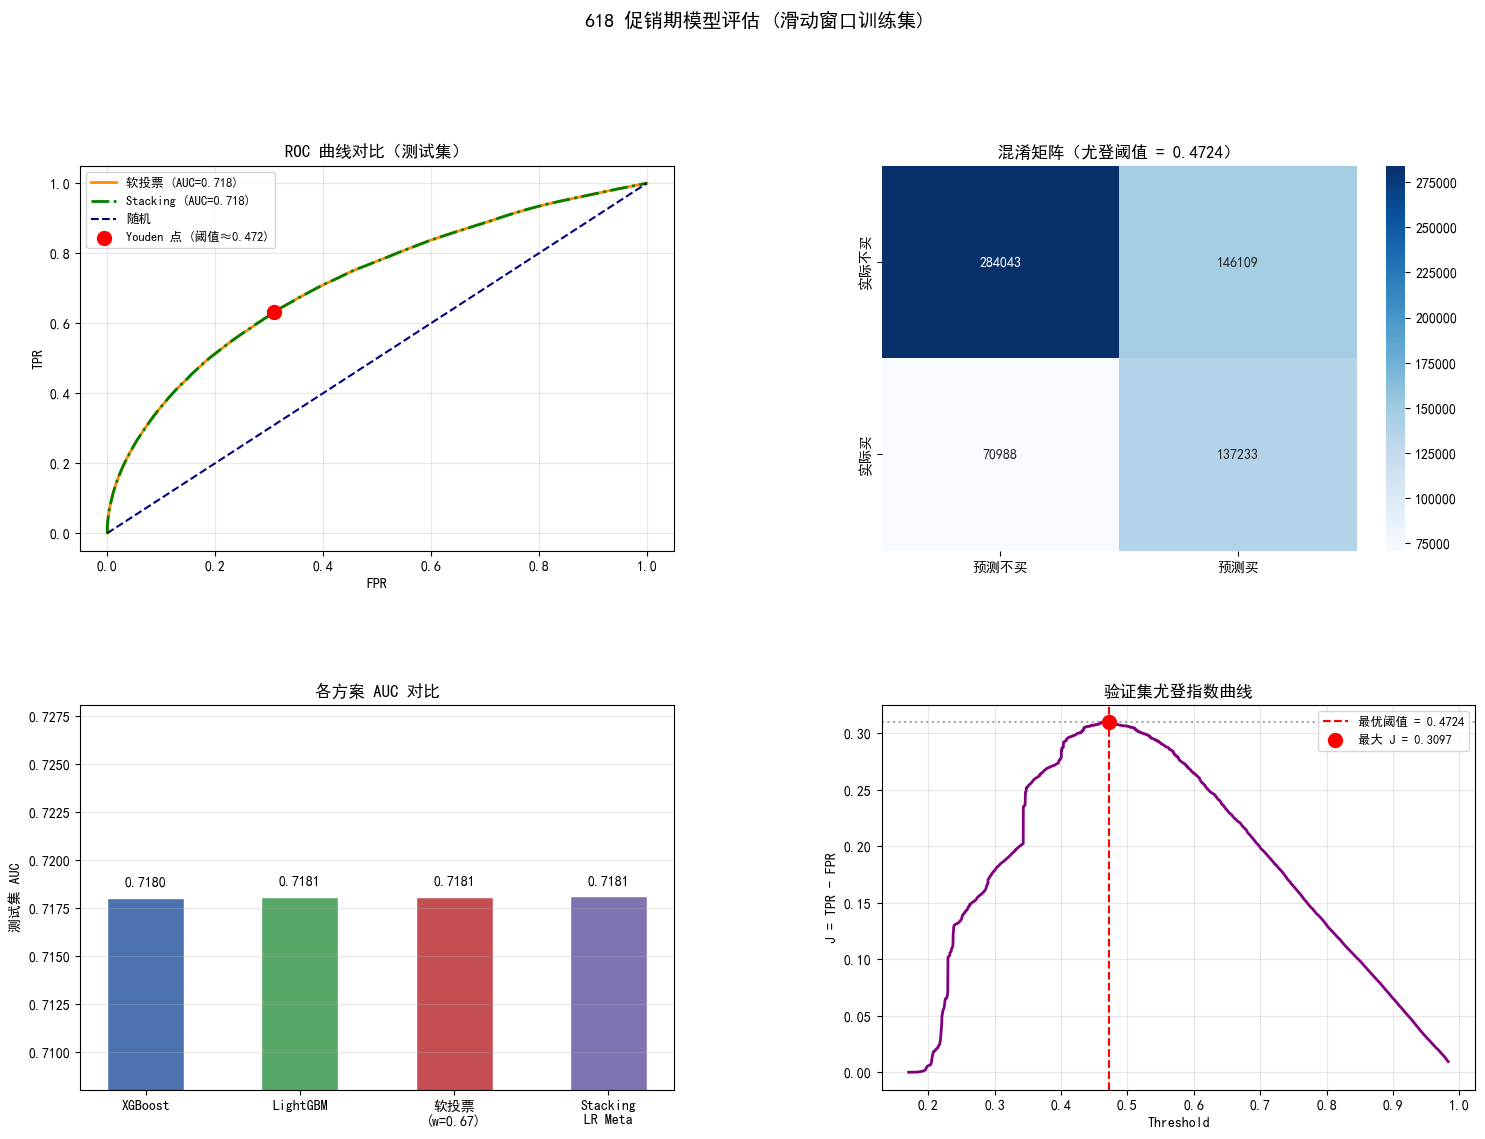

In [9]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── ROC 曲线 ──────────────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
fpr_ens, tpr_ens, _ = roc_curve(y_test, y_prob_ensemble)
fpr_stk, tpr_stk, _ = roc_curve(y_test, y_prob_test_stack)

ax0.plot(fpr_ens, tpr_ens, color='darkorange', lw=2,
         label=f'软投票 (AUC={ensemble_auc:.3f})')
ax0.plot(fpr_stk, tpr_stk, color='green', lw=2, linestyle='-.',
         label=f'Stacking (AUC={stacking_test_auc:.3f})')
ax0.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='随机')

youden_test  = tpr_ens - fpr_ens
youden_idx_t = np.argmax(youden_test)
ax0.scatter(fpr_ens[youden_idx_t], tpr_ens[youden_idx_t],
            color='red', zorder=5, s=100,
            label=f'Youden 点 (阈值≈{best_threshold:.3f})')
ax0.set_title('ROC 曲线对比（测试集）')
ax0.set_xlabel('FPR'); ax0.set_ylabel('TPR')
ax0.legend(fontsize=9); ax0.grid(True, alpha=0.3)

# ── 混淆矩阵 ──────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
cm  = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['预测不买', '预测买'],
            yticklabels=['实际不买', '实际买'])
ax1.set_title(f'混淆矩阵（尤登阈值 = {best_threshold:.4f}）')

# ── AUC 柱状图 ────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
labels_bar = ['XGBoost', 'LightGBM', f'软投票\n(w={best_w:.2f})', 'Stacking\nLR Meta']
aucs_bar   = [
    roc_auc_score(y_test, y_prob_test),
    roc_auc_score(y_test, y_prob_test_lgb),
    ensemble_auc,
    stacking_test_auc,
]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars   = ax2.bar(labels_bar, aucs_bar, color=colors, width=0.5, edgecolor='white')
ax2.set_ylim(min(aucs_bar) - 0.01, max(aucs_bar) + 0.01)
ax2.set_ylabel('测试集 AUC'); ax2.set_title('各方案 AUC 对比')
for bar, auc in zip(bars, aucs_bar):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
             f'{auc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# ── 尤登指数曲线 ──────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
step = max(1, len(thresholds_val) // 3000)
ax3.plot(thresholds_val[::step], youden_j[::step], color='purple', lw=2)
ax3.axvline(x=best_threshold, color='red', linestyle='--',
            label=f'最优阈值 = {best_threshold:.4f}')
ax3.axhline(y=youden_j[best_idx], color='gray', linestyle=':', alpha=0.7)
ax3.scatter([best_threshold], [youden_j[best_idx]],
            color='red', zorder=5, s=100, label=f'最大 J = {youden_j[best_idx]:.4f}')
ax3.set_xlabel('Threshold'); ax3.set_ylabel('J = TPR - FPR')
ax3.set_title('验证集尤登指数曲线')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.suptitle('618 促销期模型评估 (滑动窗口训练集)', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


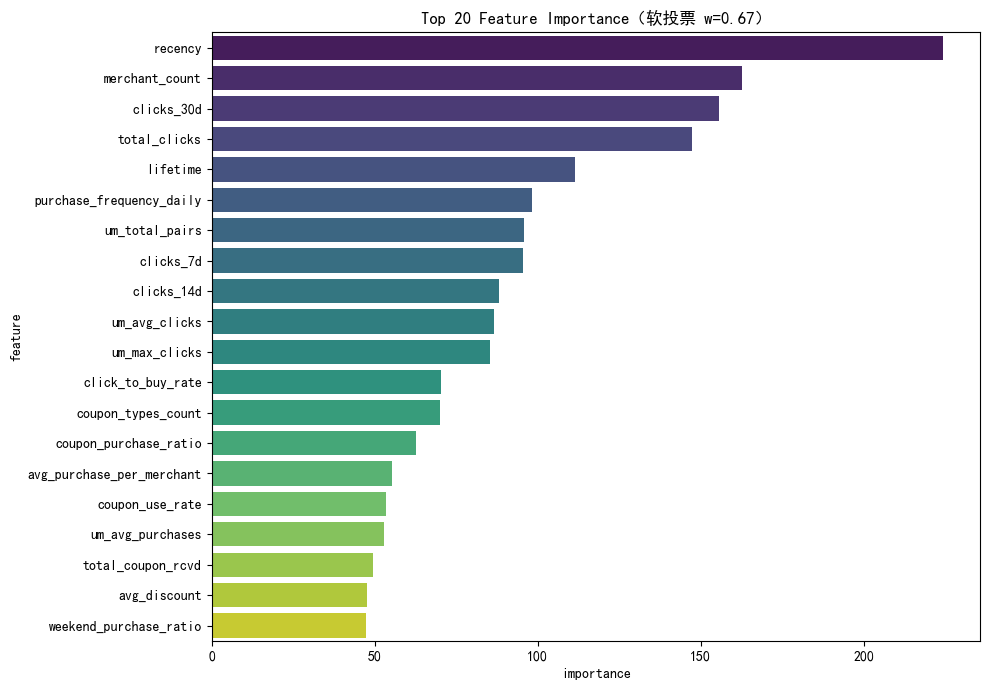

In [10]:
# Top 20 特征重要性（加权平均）
fi = (xgb_model.feature_importances_ * best_w +
      lgb_model.feature_importances_ * (1 - best_w))
fi_df = (
    pd.DataFrame({'feature': feature_cols, 'importance': fi})
      .sort_values('importance', ascending=False)
      .head(20)
)
plt.figure(figsize=(10, 7))
sns.barplot(x='importance', y='feature', data=fi_df, palette='viridis')
plt.title(f'Top 20 Feature Importance（软投票 w={best_w:.2f}）')
plt.tight_layout(); plt.show()


## 7. 模型保存

In [11]:
os.makedirs('../ml_models', exist_ok=True)

with open('../ml_models/xgb_sliding.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
with open('../ml_models/lgb_sliding.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)
with open('../ml_models/stacking_sliding.pkl', 'wb') as f:
    pickle.dump(stacking_clf, f)

metadata = {
    'feature_cols': feature_cols,
    'best_weight_xgb': float(best_w),
    'optimal_threshold': float(best_threshold),
    'test_auc_ensemble': float(ensemble_auc),
    'test_auc_stacking': float(stacking_test_auc),
    'test_f1_youden': float(f1_score(y_test, y_pred_final)),
}
with open('../ml_models/model_metadata_v2.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print('模型已保存:')
for k in ['test_auc_ensemble', 'test_auc_stacking', 'test_f1_youden',
          'best_weight_xgb', 'optimal_threshold']:
    print(f'  {k}: {metadata[k]:.4f}')


模型已保存:
  test_auc_ensemble: 0.7181
  test_auc_stacking: 0.7181
  test_f1_youden: 0.5584
  best_weight_xgb: 0.6700
  optimal_threshold: 0.4724
